In [6]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#import h5py

In [7]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7255592/sum_full_gamma_scintillator.root")
#tree = file["Primary"]
tree4 = file["DetectorGammas"]
tree5 = file["Hits"]

#df = tree.arrays(library="pd")
df4 = tree4.arrays(library="pd")
df5 = tree5.arrays(library="pd")

#df['ParticleName'] = df['ParticleName'].astype(str)


In [3]:
#attempt to merge the primary energy here with the neutrons 
#merged_df = pd.merge(df2, df, on="EventID", how="inner")

#merged_df_fill = merged_df.fillna(method="ffill")
#print(merged_df_fill)

#merged_df2 = pd.merge(df3, df, on="EventID", how="inner")

#merged_df_fill2 = merged_df2.fillna(method="ffill")
#print(merged_df_fill2)

#merged_df3 = pd.merge(df3, df2, on="EventID", how="inner")
#merged_df_fill3 = merged_df3.fillna(method="ffill")
#print(merged_df_fill3)

print(df)
print(df4)

#merged_df4 = pd.merge(df4, df, on="EventID", how="inner")
merged_df4 = df.merge(df4, on=["EventID"], how="inner")
print(merged_df4)

#merged_df_fill4 = merged_df4.fillna(method="ffill")
#print(merged_df_fill4)

#merged_df5 = pd.merge(df4, df5, on=["EventID"], how="inner")
merged_df5 = merged_df4.merge(df5, on=["EventID"], how="inner")
#merged_df_fill5 = merged_df5.fillna(method="ffill")
print(merged_df5)

merged_df5["ParticleName"] = merged_df5["ParticleName"].astype(str)

              EventID  TrackID  PDGCode  PrimaryEnergy  PrimaryPosX  \
0         100000000.0      1.0     22.0       4.430998       -510.0   
1         100000001.0      1.0     22.0       1.212120       -510.0   
2         100000002.0      1.0     22.0       8.827371       -510.0   
3         100000003.0      1.0     22.0       1.523625       -510.0   
4         100000004.0      1.0     22.0       4.901268       -510.0   
...               ...      ...      ...            ...          ...   
99999995  199999995.0      1.0     22.0       4.478874       -510.0   
99999996  199999996.0      1.0     22.0       4.164594       -510.0   
99999997  199999997.0      1.0     22.0       5.931006       -510.0   
99999998  199999998.0      1.0     22.0       6.974284       -510.0   
99999999  199999999.0      1.0     22.0       1.002985       -510.0   

          PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0           28.100446   457.830788          0.600440          0.799195   

           EventID  TrackID_x  PDGCode_x  PrimaryEnergy_x  PrimaryPosX  \
0      100001262.0        1.0       22.0         9.132257       -510.0   
1      100001262.0        1.0       22.0         9.132257       -510.0   
2      100001262.0        1.0       22.0         9.132257       -510.0   
3      100033687.0        1.0       22.0         7.814217       -510.0   
4      100033687.0        1.0       22.0         7.814217       -510.0   
...            ...        ...        ...              ...          ...   
25859  199958554.0        1.0       22.0         5.956921       -510.0   
25860  199958554.0        1.0       22.0         5.956921       -510.0   
25861  199958554.0        1.0       22.0         5.956921       -510.0   
25862  199979357.0        1.0       22.0         4.011954       -510.0   
25863  199979357.0        1.0       22.0         4.011954       -510.0   

       PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0       107.283175    21.664110         

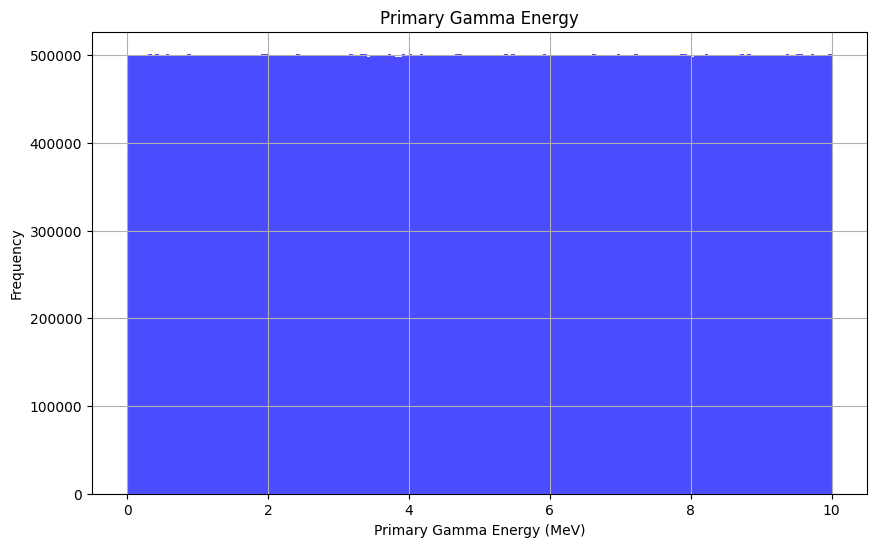

NameError: name 'merged_df_fill2' is not defined

<Figure size 1000x600 with 0 Axes>

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df['PrimaryEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Primary Gamma Energy')
plt.xlabel('Primary Gamma Energy (MeV)')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("primaryenergydistro_200Mplanargammas_scintillator.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(merged_df_fill2['KineticEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Neutron Energy at boundary of water shield/fridge')
plt.xlabel('Neutron Energy (MeV)')
plt.ylabel('Frequency')
plt.grid()
#plt.savefig("250kneutron_fullDetector_NRDistro.pdf")
plt.show()


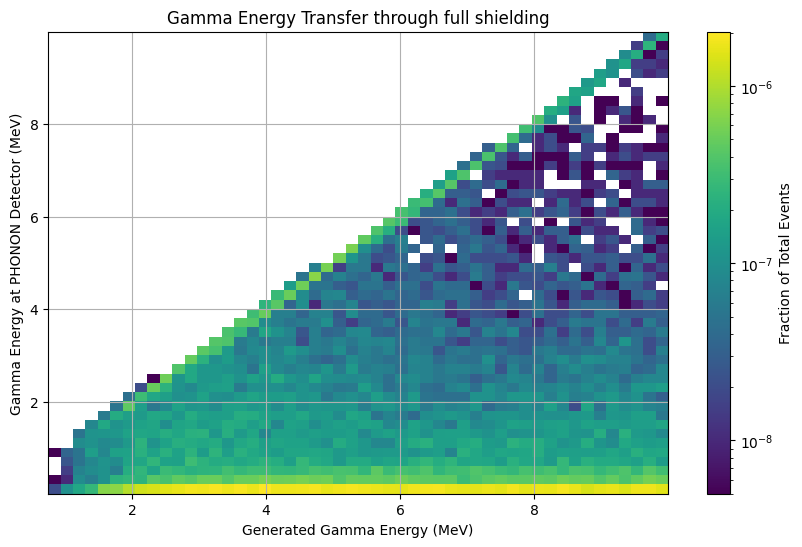

In [8]:
from matplotlib.colors import LogNorm
'''
heatmap, xedges, yedges = np.histogram2d(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through lead shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at lead/water shield boundary')
plt.grid()
plt.savefig("NeutronTransfer_LeadWaterBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through water shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.savefig("NeutronTransfer_WaterFridgeBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill3['KineticEnergy_x'], merged_df_fill3['KineticEnergy_y'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function between shielding layers')
plt.xlabel('Neutron Energy at lead/water shield boundary')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.show()
'''
#prim_mask = (merged_df4['TrackID_y'] == 1)

#prim_merged_df4 = merged_df4[prim_mask]
'''
heatmap, xedges, yedges = np.histogram2d(merged_df4['PrimaryEnergy_x'], merged_df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 100000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
#plt.scatter(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'], alpha=0.5, s=1)
#plt.imshow(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'])
plt.title('Gamma Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Gamma Energy (MeV)')
plt.ylabel('Gamma Energy at PHONON Detector (MeV)')
plt.grid()
plt.savefig("GammaTransfer_Scintillator_planargammas_FracColorBar.pdf")
plt.show()
'''

heatmap, xedges, yedges = np.histogram2d(df4['PrimaryEnergy'], df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 200000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
#plt.scatter(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'], alpha=0.5, s=1)
#plt.imshow(merged_df_fill4['PrimaryEnergy'], merged_df_fill4['KineticEnergy'])
plt.title('Gamma Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Gamma Energy (MeV)')
plt.ylabel('Gamma Energy at PHONON Detector (MeV)')
plt.grid()
plt.savefig("GammaTransfer_Scintillator_planargamma_FracColorBar.pdf")
plt.show()


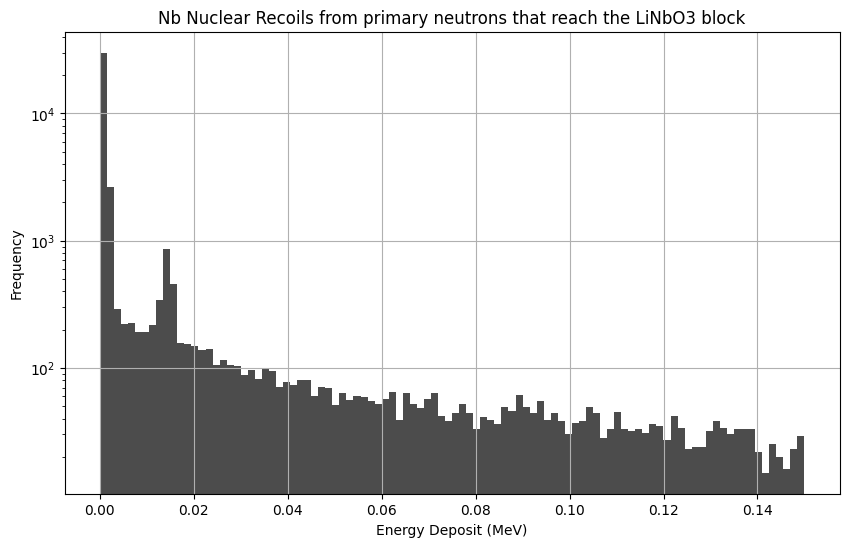

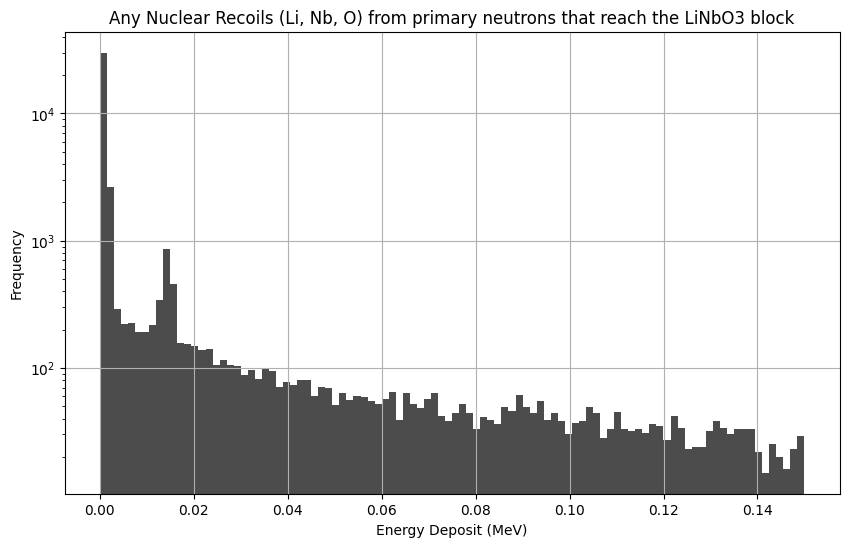

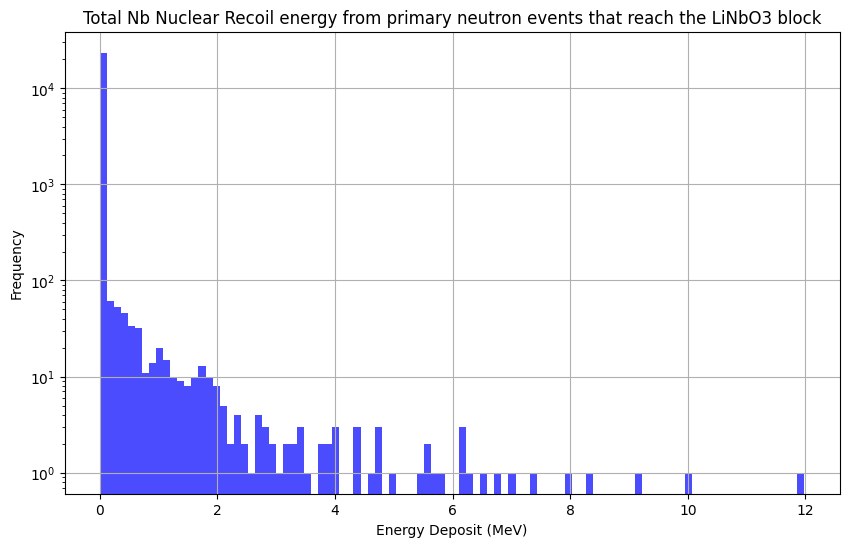

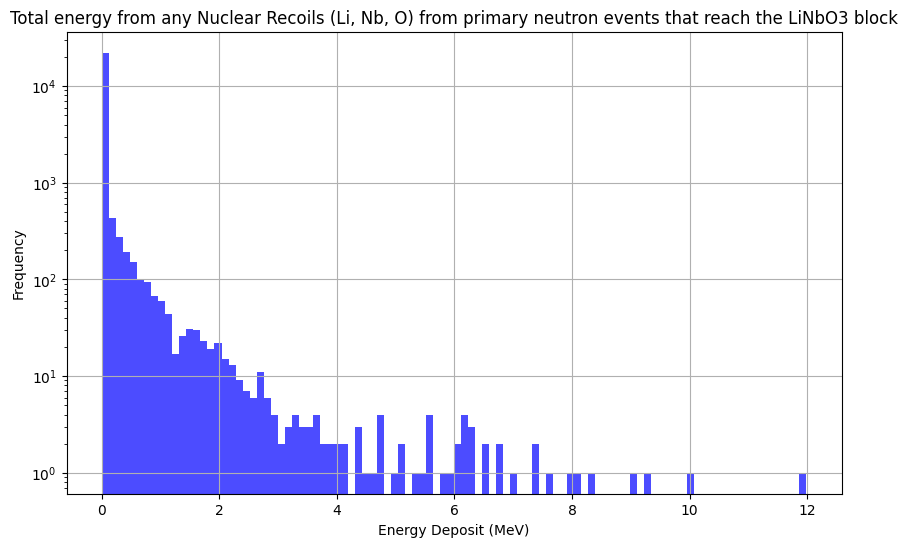

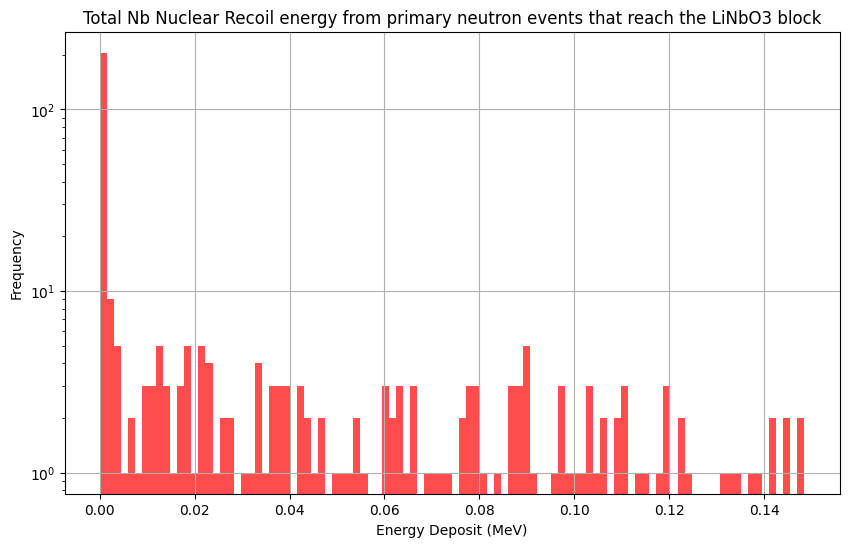

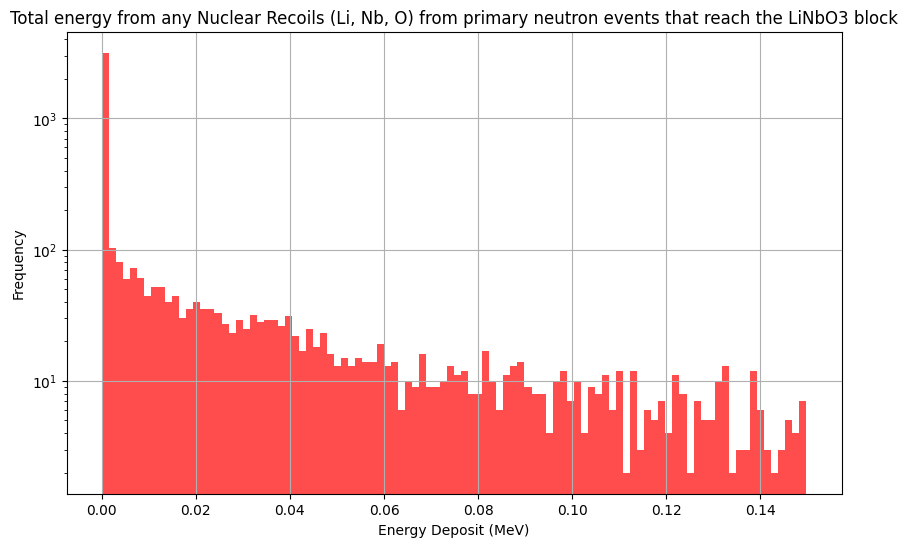

In [9]:
mask_nb = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False)
mask_nr = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False) | merged_df5["ParticleName"].str.contains('Li', case=False, na=False) | merged_df5["ParticleName"].str.contains('O', case=False, na=False)
nb_recoil_df = merged_df5[mask_nb]
nr_recoil_df = merged_df5[mask_nr]

mask_nb_roi = merged_df5["Edep"] < 0.15

nb_roi_df = merged_df5[mask_nb_roi]
nr_roi_df = merged_df5[mask_nb_roi]

plt.figure(figsize=(10,6))
plt.hist(nb_roi_df['Edep'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoil_hitlevelNb_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(nr_roi_df['Edep'], bins=100, color='black', alpha=0.7)
plt.title("Any Nuclear Recoils (Li, Nb, O) from primary neutrons that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoil_hitlevelNR_planarneutrons.pdf")
plt.show()

mask_nb_total = (merged_df4["totalNb"] > 0.0) & (merged_df4["totalNb"] < 0.15)
mask_nr_total = (merged_df4["totalNR"] > 0.0) & (merged_df4["totalNR"] < 0.15)

total_nb_df = merged_df4[mask_nb_total]
total_nr_df = merged_df4[mask_nr_total]

plt.figure(figsize=(10,6))
plt.hist(merged_df4['totalNb'], bins=100, color='blue', alpha=0.7)
plt.title("Total Nb Nuclear Recoil energy from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoils_totalNR_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged_df4['totalNR'], bins=100, color='blue', alpha=0.7)
plt.title("Total energy from any Nuclear Recoils (Li, Nb, O) from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoils_totalNR_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(total_nb_df['totalNb'], bins=100, color='red', alpha=0.7)
plt.title("Total Nb Nuclear Recoil energy from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
#plt.savefig("NuclearRecoils_totalNR_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(total_nr_df['totalNR'], bins=100, color='red', alpha=0.7)
plt.title("Total energy from any Nuclear Recoils (Li, Nb, O) from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.show()



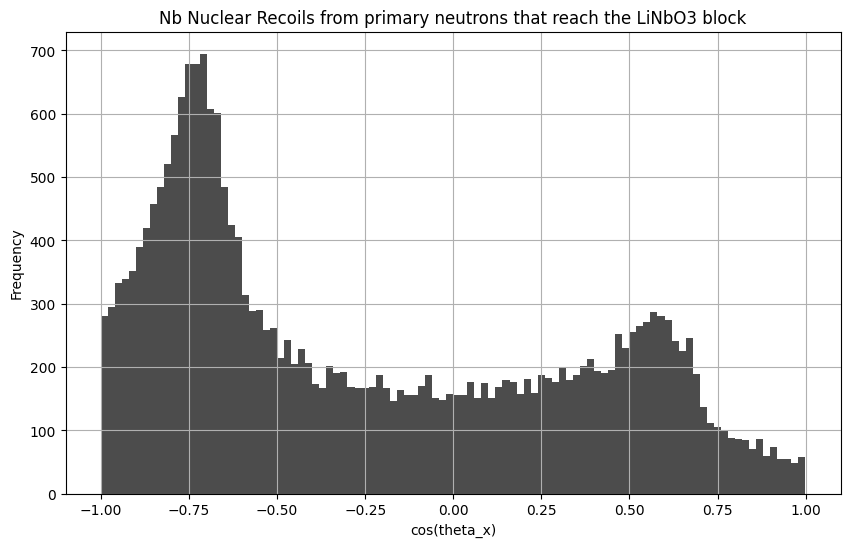

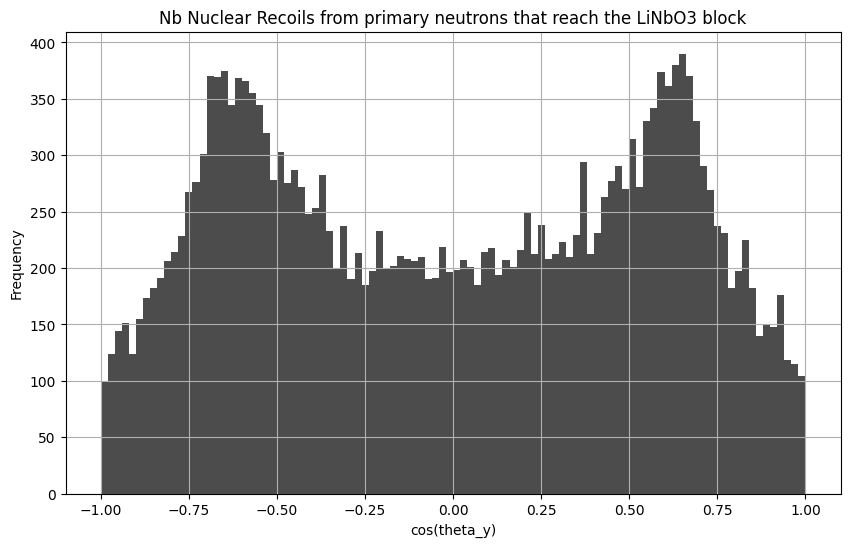

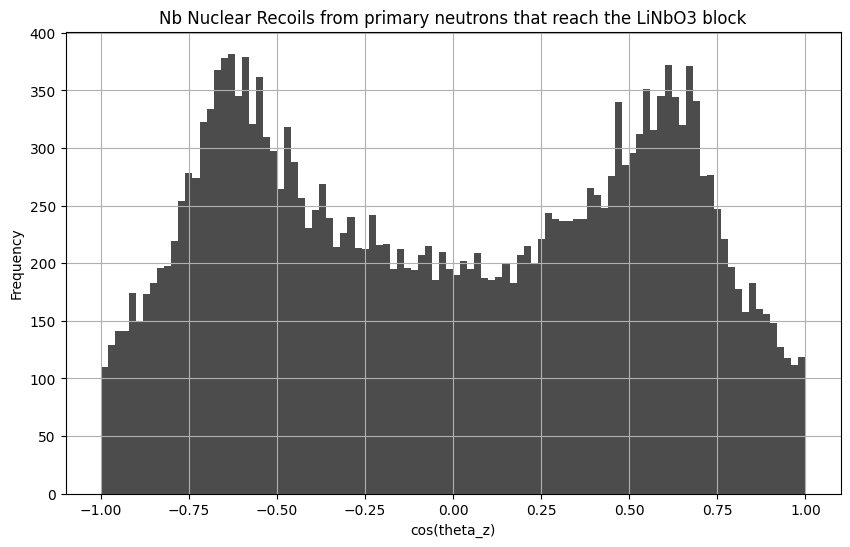

In [10]:
plt.figure(figsize=(10,6))
plt.hist(merged_df4['PositionDirX'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("cos(theta_x)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("NeutronTransfer_LiNbO3_planarsource_dirx.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged_df4['PositionDirY'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("cos(theta_y)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("NeutronTransfer_LiNbO3_planarsource_diry.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged_df4['PositionDirZ'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("cos(theta_z)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("NeutronTransfer_LiNbO3_planarsource_dirz.pdf")
plt.show()